# DetecciÃ³n de cut edges â€” YOLOv9

Pipeline:
1. Carga YOLOv9 (`michelin_v2`)
2. Inferencia filtrando solo `cut_edge` (clase 0)
3. Compara predicciones con ground truth de `new_samples`
4. MÃ©tricas reales: IoU bbox, Precision, Recall
5. Guarda visualizaciones en `outputs/figures/cut_edge_detection/`

**Colores:** verde = ground truth Â· amarillo = predicciÃ³n

## 1. Cargar modelo

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

WEIGHTS          = "../utils/runs/data/runs/michelin_v3-4/weights/best.pt"
CUT_EDGE_CLASS   = 0
CONF_THR         = 0.65
IOU_THR          = 0.50
MAX_BOX_RATIO    = 0.10
NMS_IOU          = 0.30

COLOR_GT   = (0, 220, 80)
COLOR_PRED = (255, 255, 0)

model = YOLO(WEIGHTS)
print(f"Modelo cargado: {WEIGHTS}")

Modelo cargado: ../utils/runs/data/runs/michelin_v3-4/weights/best.pt


## 2. Helpers

In [2]:
def load_gt_cut_edge(label_path, img_w, img_h):
    """
    Soporta dos formatos:
      - YOLO segmentación estándar:    class x1 y1 x2 y2 ...
      - Roboflow con annotation_id:    ann_id class x1 y1 x2 y2 ...
      - YOLO detección:                class cx cy w h
    Detecta el formato comprobando si parts[1] tiene punto decimal (coord) o no (ann_id/class).
    """
    boxes = []
    if not Path(label_path).exists():
        return boxes
    for line in Path(label_path).read_text().splitlines():
        parts = line.strip().split()
        if not parts:
            continue

        try:
            # Si parts[1] no tiene punto decimal → es entero → hay ann_id delante
            if len(parts) >= 6 and '.' not in parts[1]:
                cls    = int(parts[1])
                coords = list(map(float, parts[2:]))
            else:
                cls    = int(parts[0])
                coords = list(map(float, parts[1:]))
        except (ValueError, IndexError):
            continue

        if cls != CUT_EDGE_CLASS:
            continue

        if len(coords) == 4:
            # Bbox estándar: cx cy w h
            cx, cy, w, h = coords
            x1 = (cx - w / 2) * img_w
            y1 = (cy - h / 2) * img_h
            x2 = (cx + w / 2) * img_w
            y2 = (cy + h / 2) * img_h
        else:
            # Polígono: x1 y1 x2 y2 ... → bbox envolvente
            xs = [coords[i] * img_w for i in range(0, len(coords), 2)]
            ys = [coords[i] * img_h for i in range(1, len(coords), 2)]
            x1, y1, x2, y2 = min(xs), min(ys), max(xs), max(ys)

        boxes.append([x1, y1, x2, y2])
    return boxes


def bbox_iou(a, b):
    ix1 = max(a[0], b[0]);  iy1 = max(a[1], b[1])
    ix2 = min(a[2], b[2]);  iy2 = min(a[3], b[3])
    inter  = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    union  = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def nms_preds(raw_preds, iou_thr=NMS_IOU):
    raw_preds = sorted(raw_preds, key=lambda p: float(p[1]), reverse=True)
    keep = []
    for box_i, conf_i in raw_preds:
        bi = [int(v) for v in box_i]
        if any(bbox_iou(bi, [int(v) for v in bj]) >= iou_thr for bj, _ in keep):
            continue
        keep.append((box_i, conf_i))
    return keep


def match_predictions(gt_boxes, pred_boxes, iou_thr=IOU_THR):
    matched_gt   = set()
    matched_pred = set()
    tp_ious = []
    for pi, pred in enumerate(pred_boxes):
        best_iou, best_gi = 0.0, -1
        for gi, gt in enumerate(gt_boxes):
            if gi in matched_gt:
                continue
            iou = bbox_iou(pred, gt)
            if iou > best_iou:
                best_iou, best_gi = iou, gi
        if best_iou >= iou_thr:
            tp_ious.append(best_iou)
            matched_gt.add(best_gi)
            matched_pred.add(pi)
    n_fp = len(pred_boxes) - len(matched_pred)
    n_fn = len(gt_boxes)   - len(matched_gt)
    return tp_ious, n_fp, n_fn


print("Helpers listos.")

Helpers listos.


## 3. Test sobre una imagen

GT cut edges: 2  |  Predichos: 2
TP: 2  FP: 0  FN: 0
IoU medio (TP): 0.836

--- Diagnóstico IoU por predicción ---
  pred[0] conf=0.92  IoU_max=0.844  box=[303, 868, 344, 1135]
  pred[1] conf=0.90  IoU_max=0.829  box=[309, 168, 359, 547]
--- GT boxes ---
  gt[0]  box=[304, 837, 343, 1131]
  gt[1]  box=[313, 168, 354, 542]


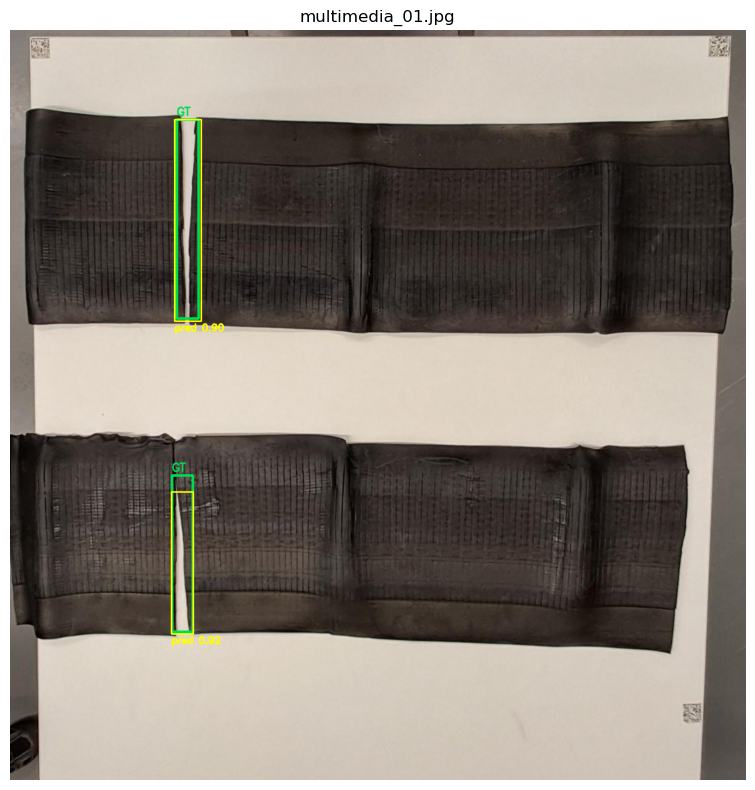

In [3]:
DATA_ROOT = Path("../data/segmentation_cut_edge")

sample_img = sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))[0]
sample_lbl = DATA_ROOT / "train" / "labels" / (sample_img.stem + ".txt")

img_bgr = cv2.imread(str(sample_img))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W    = img_rgb.shape[:2]

gt_boxes = load_gt_cut_edge(sample_lbl, W, H)
preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]

raw_preds  = [(b.xyxy[0], float(b.conf[0])) for b in preds.boxes if int(b.cls[0]) == CUT_EDGE_CLASS]
raw_preds  = [p for p in raw_preds
              if (int(p[0][2])-int(p[0][0])) * (int(p[0][3])-int(p[0][1])) / (H * W) <= MAX_BOX_RATIO]
raw_preds  = nms_preds(raw_preds)[:2]
pred_boxes = [[*map(int, p[0])] for p in raw_preds]
pred_confs = [p[1] for p in raw_preds]

tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)
print(f"GT cut edges: {len(gt_boxes)}  |  Predichos: {len(pred_boxes)}")
print(f"TP: {len(tp_ious)}  FP: {n_fp}  FN: {n_fn}")
if tp_ious:
    print(f"IoU medio (TP): {np.mean(tp_ious):.3f}")

print("\n--- Diagnóstico IoU por predicción ---")
for pi, pred in enumerate(pred_boxes):
    ious = [bbox_iou(pred, gt) for gt in gt_boxes]
    iou_str = f"{max(ious):.3f}" if ious else "—"
    print(f"  pred[{pi}] conf={pred_confs[pi]:.2f}  IoU_max={iou_str}  box={pred}")
print("--- GT boxes ---")
for gi, gt in enumerate(gt_boxes):
    print(f"  gt[{gi}]  box={[int(v) for v in gt]}")

overlay = img_rgb.copy()
for box in gt_boxes:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 220, 80), 3)
    cv2.putText(overlay, "GT", (x1, max(y1-8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 220, 80), 2)
for box, conf in zip(pred_boxes, pred_confs):
    x1, y1, x2, y2 = box
    cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_PRED, 2)
    cv2.putText(overlay, f"pred {conf:.2f}", (x1, y2+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)

clean_stem = sample_img.stem.split("_jpg.rf.")[0]
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.imshow(overlay)
ax.set_title(f"{clean_stem}.jpg")
ax.axis("off")
plt.tight_layout()
plt.show()

## 4. DiagnÃ³stico por imagen

In [4]:
## Cambia TARGET para inspeccionar cualquier imagen
TARGET = "multimedia_01_jpg.rf.VXa1Uc1sODZfNRA5yypB.jpg"

img_path = DATA_ROOT / "train" / "images" / TARGET
lbl_path = DATA_ROOT / "train" / "labels" / (Path(TARGET).stem + ".txt")
if not img_path.exists():
    img_path = DATA_ROOT / "valid" / "images" / TARGET
    lbl_path = DATA_ROOT / "valid" / "labels" / (Path(TARGET).stem + ".txt")

img_bgr = cv2.imread(str(img_path))
H, W    = img_bgr.shape[:2]

gt_boxes = load_gt_cut_edge(lbl_path, W, H)
preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]

print(f"Imagen: {TARGET}  ({W}Ã—{H})")
print(f"\n{'#':<5} {'conf':>6}  {'Ã¡rea%':>6}  box")
print("-" * 60)
for i, b in enumerate(preds.boxes):
    if int(b.cls[0]) != CUT_EDGE_CLASS:
        continue
    x1, y1, x2, y2 = map(int, b.xyxy[0])
    conf = float(b.conf[0])
    area = (x2 - x1) * (y2 - y1) / (H * W) * 100
    ious = [bbox_iou([x1, y1, x2, y2], gt) for gt in gt_boxes]
    iou_str = "  ".join(f"{v:.3f}" for v in ious) if ious else "â€”"
    print(f"[{i}]   {conf:.3f}   {area:5.1f}%   IoUs=[{iou_str}]   [{x1},{y1},{x2},{y2}]")

print(f"\nGT boxes ({len(gt_boxes)}):")
for gi, gt in enumerate(gt_boxes):
    x1, y1, x2, y2 = [int(v) for v in gt]
    area = (x2 - x1) * (y2 - y1) / (H * W) * 100
    print(f"  gt[{gi}]  Ã¡rea={area:.2f}%  [{x1},{y1},{x2},{y2}]")

Imagen: multimedia_01_jpg.rf.VXa1Uc1sODZfNRA5yypB.jpg  (1383Ã—1410)

#       conf  Ã¡rea%  box
------------------------------------------------------------
[10]   0.919     0.6%   IoUs=[0.844  0.000]   [303,868,344,1135]
[12]   0.901     1.0%   IoUs=[0.000  0.829]   [309,168,359,547]
[19]   0.812     0.4%   IoUs=[0.000  0.509]   [317,297,350,547]
[22]   0.733     0.3%   IoUs=[0.000  0.302]   [318,311,339,559]
[25]   0.703     0.3%   IoUs=[0.000  0.373]   [316,239,338,505]
[27]   0.687     0.4%   IoUs=[0.552  0.000]   [303,879,331,1153]

GT boxes (2):
  gt[0]  Ã¡rea=0.59%  [304,837,343,1131]
  gt[1]  Ã¡rea=0.79%  [313,168,354,542]


## 5. EvaluaciÃ³n sobre todo el dataset (train + valid)

In [5]:
DATA_ROOT = Path("../data/segmentation_cut_edge")

all_imgs = [
    (img, DATA_ROOT / "train" / "labels" / (img.stem + ".txt"))
    for img in sorted((DATA_ROOT / "train" / "images").glob("*.jpg"))
] + [
    (img, DATA_ROOT / "valid" / "labels" / (img.stem + ".txt"))
    for img in sorted((DATA_ROOT / "valid" / "images").glob("*.jpg"))
]
print(f"Total imágenes: {len(all_imgs)}")

total_tp, total_fp, total_fn = 0, 0, 0
all_tp_ious = []
per_image   = []

for img_path, lbl_path in all_imgs:
    img_bgr  = cv2.imread(str(img_path))
    H, W     = img_bgr.shape[:2]
    gt_boxes = load_gt_cut_edge(lbl_path, W, H)
    preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]

    raw_preds  = [(b.xyxy[0], float(b.conf[0])) for b in preds.boxes
                  if int(b.cls[0]) == CUT_EDGE_CLASS
                  and (int(b.xyxy[0][2])-int(b.xyxy[0][0])) * (int(b.xyxy[0][3])-int(b.xyxy[0][1])) / (H * W) <= MAX_BOX_RATIO]
    raw_preds  = nms_preds(raw_preds)[:2]
    pred_boxes = [[*map(int, p[0])] for p in raw_preds]

    tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)
    total_tp += len(tp_ious)
    total_fp += n_fp
    total_fn += n_fn
    all_tp_ious.extend(tp_ious)

    per_image.append({
        "name":     img_path.name,
        "gt":       len(gt_boxes),
        "pred":     len(pred_boxes),
        "tp":       len(tp_ious),
        "fp":       n_fp,
        "fn":       n_fn,
        "iou_mean": np.mean(tp_ious) if tp_ious else None,
    })

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall    = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n{'='*55}")
print(f"TP: {total_tp}  FP: {total_fp}  FN: {total_fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")
if all_tp_ious:
    print(f"IoU medio (TP): {np.mean(all_tp_ious):.3f}")

print(f"\n{'Imagen':<50} {'GT':>4} {'Pred':>5} {'TP':>4} {'FP':>4} {'FN':>4} {'IoU':>6}")
print("-" * 80)
for r in per_image:
    iou_str = f"{r['iou_mean']:.3f}" if r["iou_mean"] is not None else "  — "
    print(f"{r['name']:<50} {r['gt']:>4} {r['pred']:>5} {r['tp']:>4} {r['fp']:>4} {r['fn']:>4} {iou_str:>6}")

Total imágenes: 22

TP: 29  FP: 6  FN: 5
Precision: 0.829
Recall:    0.853
F1:        0.841
IoU medio (TP): 0.674

Imagen                                               GT  Pred   TP   FP   FN    IoU
--------------------------------------------------------------------------------
multimedia_01_jpg.rf.VXa1Uc1sODZfNRA5yypB.jpg         2     2    2    0    0  0.836
multimedia_02_jpg.rf.Oj3RZ61LrtxiLIH6Q2qV.jpg         2     2    1    1    1  0.793
multimedia_04_jpg.rf.MGHdsSXWAqCvpoTV9eEz.jpg         2     2    2    0    0  0.728
multimedia_05_jpg.rf.UmwCstSbCbadDh62kdyj.jpg         2     2    2    0    0  0.657
multimedia_07_jpg.rf.rzxqe1IXC3fkfze6QTtc.jpg         2     2    2    0    0  0.680
multimedia_08_jpg.rf.Z7rzyNv5BaX4JsejH44T.jpg         2     2    2    0    0  0.587
multimedia_09_jpg.rf.4yp5FkHpPSDiJCr0gnE6.jpg         2     2    1    1    1  0.889
multimedia_10_jpg.rf.wxfQCr6OUG88R64iwuod.jpg         2     2    2    0    0  0.640
multimedia_11_jpg.rf.U2X6VMrXEcfhMHZ1Plqu.jpg   

MÉTRICA                 VALOR
----------------------------------------
Precision              0.829  ████████████████
Recall                 0.853  █████████████████
F1 Score               0.841  ████████████████
IoU (mean TP)          0.674  █████████████
TP: 29  FP: 6  FN: 5  |  Imágenes: 22


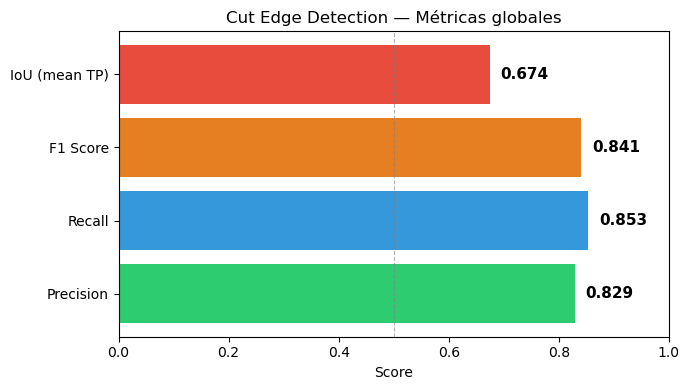

In [6]:
## Resumen de métricas
iou_mean = np.mean(all_tp_ious) if all_tp_ious else 0.0

metrics = {
    "Precision": precision,
    "Recall":    recall,
    "F1 Score":  f1,
    "IoU (mean TP)": iou_mean,
}

print("=" * 40)
print(f"{'MÉTRICA':<20} {'VALOR':>8}")
print("-" * 40)
for name, val in metrics.items():
    bar = "█" * int(val * 20)
    print(f"{name:<20} {val:>7.3f}  {bar}")
print("=" * 40)
print(f"TP: {total_tp}  FP: {total_fp}  FN: {total_fn}  |  Imágenes: {len(per_image)}")

fig, ax = plt.subplots(figsize=(7, 4))
names = list(metrics.keys())
vals  = list(metrics.values())
colors = ["#2ecc71", "#3498db", "#e67e22", "#e74c3c"]
bars = ax.barh(names, vals, color=colors)
ax.set_xlim(0, 1)
ax.set_xlabel("Score")
ax.set_title("Cut Edge Detection — Métricas globales")
for bar, val in zip(bars, vals):
    ax.text(min(val + 0.02, 0.97), bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=11, fontweight="bold")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

## 6. Guardar visualizaciones

In [7]:
OUT_DIR = Path("outputs/figures/cut_edge_detection")
OUT_DIR.mkdir(parents=True, exist_ok=True)

for img_path, lbl_path in all_imgs:
    img_bgr  = cv2.imread(str(img_path))
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H, W     = img_rgb.shape[:2]
    gt_boxes = load_gt_cut_edge(lbl_path, W, H)
    preds    = model(img_bgr, verbose=False, conf=CONF_THR)[0]

    raw_preds  = [(b.xyxy[0], float(b.conf[0])) for b in preds.boxes if int(b.cls[0]) == CUT_EDGE_CLASS]
    raw_preds  = [p for p in raw_preds
                  if (int(p[0][2])-int(p[0][0])) * (int(p[0][3])-int(p[0][1])) / (H * W) <= MAX_BOX_RATIO]
    raw_preds  = nms_preds(raw_preds)[:2]
    pred_boxes = [[*map(int, p[0])] for p in raw_preds]
    pred_confs = [p[1] for p in raw_preds]

    tp_ious, n_fp, n_fn = match_predictions(gt_boxes, pred_boxes)

    overlay = img_rgb.copy()
    for box in gt_boxes:
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_GT, 3)
        cv2.putText(overlay, "GT", (x1, max(y1-8, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.65, COLOR_GT, 2)
    for box, conf in zip(pred_boxes, pred_confs):
        x1, y1, x2, y2 = box
        cv2.rectangle(overlay, (x1, y1), (x2, y2), COLOR_PRED, 2)
        cv2.putText(overlay, f"pred {conf:.2f}", (x1, y2+18), cv2.FONT_HERSHEY_SIMPLEX, 0.6, COLOR_PRED, 2)

    iou_str  = f"IoU={np.mean(tp_ious):.3f}" if tp_ious else "IoU=nulo"
    subtitle = f"GT={len(gt_boxes)}  Pred={len(pred_boxes)}  TP={len(tp_ious)}  FP={n_fp}  FN={n_fn}  {iou_str}"

    clean_stem = img_path.stem.split("_jpg.rf.")[0]
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(overlay)
    ax.set_title("GT (verde) vs Pred (verde claro)")
    ax.axis("off")
    fig.suptitle(f"{img_path.name}\n{subtitle}", fontsize=10, fontweight="bold")
    plt.tight_layout()

    plt.savefig(OUT_DIR / f"{clean_stem}.jpg", dpi=100, bbox_inches="tight")
    plt.close()
    print(f"  {clean_stem}.jpg → {subtitle}")

print(f"\nFiguras guardadas en: {OUT_DIR.resolve()}")

  multimedia_01.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.836
  multimedia_02.jpg → GT=2  Pred=2  TP=1  FP=1  FN=1  IoU=0.793
  multimedia_04.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.728
  multimedia_05.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.657
  multimedia_07.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.680
  multimedia_08.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.587
  multimedia_09.jpg → GT=2  Pred=2  TP=1  FP=1  FN=1  IoU=0.889
  multimedia_10.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.640
  multimedia_11.jpg → GT=2  Pred=2  TP=1  FP=1  FN=1  IoU=0.574
  multimedia_12.jpg → GT=2  Pred=2  TP=1  FP=1  FN=1  IoU=0.631
  multimedia_13.jpg → GT=2  Pred=2  TP=1  FP=1  FN=1  IoU=0.551
  multimedia_14.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.609
  multimedia_15.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.583
  multimedia_17.jpg → GT=2  Pred=2  TP=2  FP=0  FN=0  IoU=0.616
  multimedia_18.jpg → GT=0  Pred=0  TP=0  FP=0  FN=0  IoU=nulo
  multimedia_19.jpg → GT=0  Pred=1  TP=0 

## 7. Exportar detecciones a JSON

Guarda los bboxes detectados sobre las imágenes raw en .
Este fichero es la entrada del notebook de segmentación EfficientSAM.

In [8]:
import json

RAW_DIR  = Path("../data/raw")
OUT_JSON = Path("outputs/detections/cut_edge_detections.json")
OUT_JSON.parent.mkdir(parents=True, exist_ok=True)

image_paths = sorted(RAW_DIR.glob("*.jpg"))
print(f"Imágenes a procesar: {len(image_paths)}")

detections = {}

for img_path in image_paths:
    img_bgr = cv2.imread(str(img_path))
    H, W    = img_bgr.shape[:2]
    preds   = model(img_bgr, verbose=False, conf=CONF_THR)[0]

    raw = [
        (b.xyxy[0], float(b.conf[0]))
        for b in preds.boxes
        if int(b.cls[0]) == CUT_EDGE_CLASS
        and (int(b.xyxy[0][2])-int(b.xyxy[0][0])) * (int(b.xyxy[0][3])-int(b.xyxy[0][1])) / (H * W) <= MAX_BOX_RATIO
    ]
    raw = nms_preds(raw)[:2]

    detections[img_path.name] = [
        {"bbox": [*map(int, box)], "conf": round(conf, 4)}
        for box, conf in raw
    ]
    print(f"  {img_path.name}: {len(detections[img_path.name])} detecciones")

OUT_JSON.write_text(json.dumps(detections, indent=2))
print(f"\nGuardado en: {OUT_JSON.resolve()}")

Imágenes a procesar: 22
  multimedia_01.jpg: 2 detecciones
  multimedia_02.jpg: 2 detecciones
  multimedia_03.jpg: 2 detecciones
  multimedia_04.jpg: 2 detecciones
  multimedia_05.jpg: 2 detecciones
  multimedia_06.jpg: 2 detecciones
  multimedia_07.jpg: 2 detecciones
  multimedia_08.jpg: 2 detecciones
  multimedia_09.jpg: 2 detecciones
  multimedia_10.jpg: 2 detecciones
  multimedia_11.jpg: 2 detecciones
  multimedia_12.jpg: 2 detecciones
  multimedia_13.jpg: 2 detecciones
  multimedia_14.jpg: 2 detecciones
  multimedia_15.jpg: 2 detecciones
  multimedia_16.jpg: 2 detecciones
  multimedia_17.jpg: 2 detecciones
  multimedia_18.jpg: 0 detecciones
  multimedia_19.jpg: 1 detecciones
  multimedia_20.jpg: 0 detecciones
  multimedia_21.jpg: 0 detecciones
  multimedia_22.jpg: 0 detecciones

Guardado en: C:\Users\jaime\Proyectos\VA_RetoMichelin\docs\4_models\GIDIA_VA_Proyect_Grupo1\models\Jaime\test\outputs\detections\cut_edge_detections.json
